# Validation against sncosmo

{func}`saltjax.fit_salt` is meant to give **the same output** as `sncosmo.fit_lc`: same SALT2 model, same $\chi^2$,
same model-covariance procedure, same Milky Way dust. This page checks it step by step on simulated SNe Ia:
the interpolation kernel, the edge rule of that kernel, the model fluxes and covariances, the fitted parameters and errors,
the $\chi^2$ at both solutions, and the pulls against the simulated truth.

:::{note}
The simulation uses [skysurvey](https://github.com/MickaelRigault/skysurvey), and the sncosmo reference fits use
`skysurvey.lcfit.fit_salt`, which calls `sncosmo.fit_lc` target by target. Speed is covered in [another page](./speed.ipynb).
:::

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
import sncosmo
from shapely import geometry

import skysurvey
from skysurvey.tools import utils
from skysurvey.lcfit import fit_salt
import saltjax
from saltjax.data import LC_KEYS, FIT_KEYS

warnings.filterwarnings("ignore", category=RuntimeWarning)  # sncosmo log10 warnings on negative fluxes
print(f"saltjax {saltjax.__version__} | sncosmo {sncosmo.__version__} | jax {jax.__version__} | skysurvey {skysurvey.__version__}")

saltjax 0.1.0 | sncosmo 2.13.0 | jax 0.10.2 | skysurvey 1.4.0


## Simulate a dataset

We draw about 800 SNe Ia with Milky Way extinction (E(B-V) from the Planck dust map), and observe them with a seeded
ZTF-like survey: random pointings, a 2 deg radius footprint, *g*, *r* and *i* bands. We keep the SNe with at least 7 detections.

:::{note}
The skysurvey target draw cannot be seeded yet, so the sample, and the exact numbers below, change slightly from
one run to the next. The conclusions do not.
:::

In [2]:
rng = np.random.default_rng(1)
snia = skysurvey.SNeIa.from_draw(size=800, zmax=0.12, tstart=59_000, tstop=59_100,
                                 radec={"ra_range": [200, 250], "dec_range": [-20, 10]},
                                 effect=skysurvey.effects.mw_extinction)
size = 25_000
logs = {"gain": 1, "zp": 30, "skynoise": rng.normal(size=size, loc=400, scale=20),
        "mjd": rng.uniform(58_950, 59_200, size=size),
        "band": rng.choice(["ztfg", "ztfr", "ztfi"], size=size)}
logs["ra"], logs["dec"] = utils.random_radec(size=size, ra_range=[200, 250], dec_range=[-20, 10], rng=rng)
survey = skysurvey.Survey.from_pointings(logs, footprint=geometry.Point(0, 0).buffer(2))

dset = skysurvey.DataSet.from_targets_and_survey(snia, survey, seed=1)
dset.data["zpsys"] = "ab"   # needed by sncosmo.fit_lc (saltjax does not need it)
ndet = dset.get_ndetection()
index = list(ndet[ndet >= 7].index)
data, targets = dset.data, dset.targets.data
truth = targets.loc[index]
print(f"{len(index)} SNe Ia with >= 7 detections, {len(data):,} observations")

798 SNe Ia with >= 7 detections, 134,253 observations


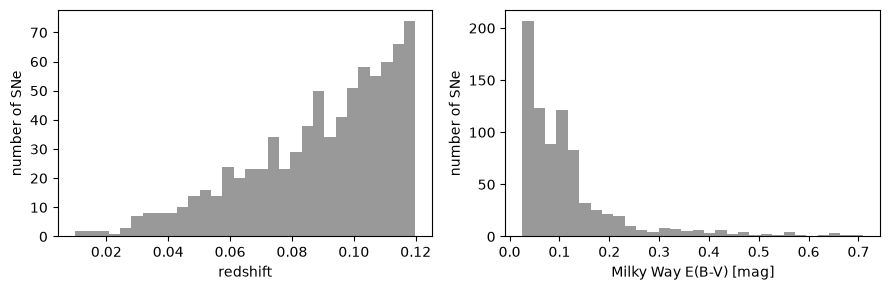

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(truth["z"], bins=30, color="0.6")
axes[0].set_xlabel("redshift")
axes[1].hist(truth["mwebv"], bins=30, color="0.6")
axes[1].set_xlabel("Milky Way E(B-V) [mag]")
for ax in axes:
    ax.set_ylabel("number of SNe")
fig.tight_layout()

## The interpolation kernel is sncosmo's

sncosmo's `BicubicInterpolator` (the same as snfit's) uses a Keys cubic-convolution kernel with $a=-0.5$, linear in the
first and last interval and zero outside the grid. We evaluate $M_0$ at random phases (at wavelength nodes) with sncosmo, and
with {func}`saltjax.kernel_weights` applied to the values at the phase nodes.

max relative difference: 2.4e-15


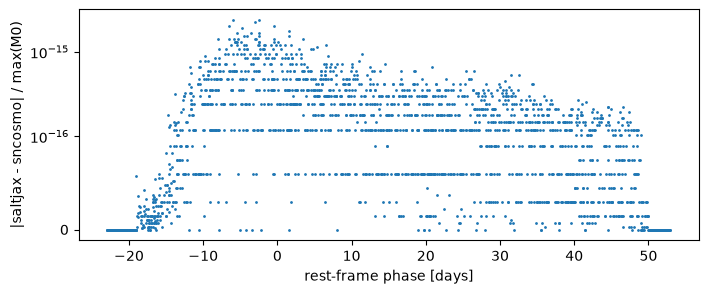

In [4]:
src = sncosmo.get_source("salt2")
wave = src._wave[[300, 700, 1000]]
phase = np.sort(np.random.default_rng(0).uniform(src._phase[0] - 3, src._phase[-1] + 3, 2000))
ref = src._model["M0"](phase, wave)
idx, w = saltjax.kernel_weights(phase - src._phase[0], len(src._phase))
mine = np.einsum("pj,pjw->pw", w, src._model["M0"](src._phase, wave)[idx])
kernel_diff = np.abs(mine - ref).max() / np.abs(ref).max()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(phase, np.abs(mine - ref).max(axis=1) / np.abs(ref).max(), ".", ms=2)
ax.set_xlabel("rest-frame phase [days]")
ax.set_ylabel("|saltjax - sncosmo| / max(M0)")
ax.set_yscale("symlog", linthresh=1e-16)
print(f"max relative difference: {kernel_diff:.1e}")

## The edge-interval rule

There is a subtlety. The kernel is two-dimensional, and when the **phase** falls in the first or last interval of the grid,
sncosmo switches to linear interpolation in **both** dimensions, wavelength included. A purely separable model (cubic in
wavelength, then the kernel in phase) is therefore wrong there, at wavelengths between the nodes.

`saltjax` reproduces this: its tables hold, for the two nodes of each edge interval, the surfaces interpolated *linearly*
in wavelength (see `saltjax.tables`). For SALT2 the first interval is $[-20, -19]$ days for $M_0$ and $M_1$, and
$[-19.5, -18.5]$ days for the LCRV and errscale surfaces. We compare $M_0$ and errscale at wavelengths between the nodes,
for phases spanning the first two intervals, with three methods: sncosmo, a naive separable model, and the `saltjax` rule
(using internal functions of `saltjax`).

In [5]:
from saltjax import tables as sjt
from saltjax.model import _interp

surfaces = sjt._load_surfaces(sjt._get_modeldir(src), src._SCALE_FACTOR)
ph = np.linspace(-20, -17.5, 501)
edge_check = {}
for key in ["M0", "errscale"]:
    s = surfaces[key]
    wv = s.wave[[10, 30, 50]] + 0.37 * (s.wave[1] - s.wave[0])     # between the wavelength nodes
    ref = src._model[key](ph, wv)                                   # sncosmo, shape (phase, wave)
    T, Te = s.at_nodes(wv).T, s.at_nodes(wv, list(sjt.EDGE_NODES), linear=True).T
    idx, w = saltjax.kernel_weights((ph - s.phase[0]) / (s.phase[1] - s.phase[0]), len(s.phase))
    naive = np.einsum("pj,wpj->pw", w, T[:, idx])                   # separable: cubic in wavelength
    P, W = np.meshgrid(ph, np.arange(len(wv)), indexing="ij")
    with jax.enable_x64(True):
        rule = np.asarray(_interp(jnp.asarray(T), jnp.asarray(Te), jnp.asarray(W.ravel()),
                                  jnp.asarray(P.ravel()),
                                  s.phase[0], s.phase[1] - s.phase[0], len(s.phase))).reshape(P.shape)
    scale = np.abs(ref).max()
    edge_check[key] = {"naive separable": np.abs(naive - ref).max(1) / scale,
                       "saltjax": np.abs(rule - ref).max(1) / scale}

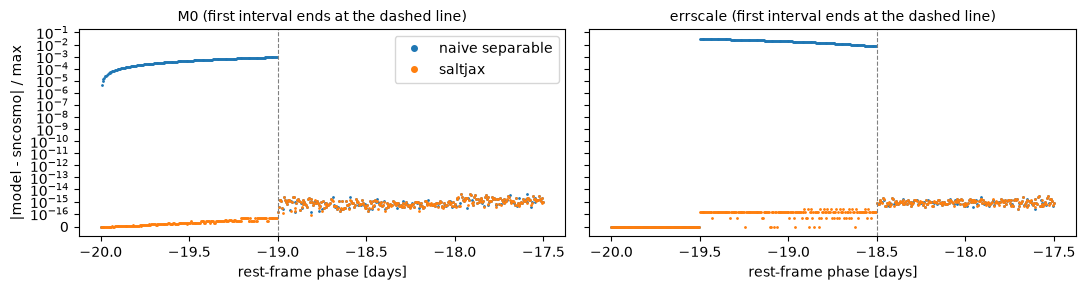

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, (key, res) in zip(axes, edge_check.items()):
    for label, d in res.items():
        ax.plot(ph, d, ".", ms=2, label=label)
    ax.axvline(surfaces[key].phase[1], color="0.5", lw=0.8, ls="--")
    ax.set_title(f"{key} (first interval ends at the dashed line)", fontsize=10)
    ax.set_xlabel("rest-frame phase [days]")
    ax.set_yscale("symlog", linthresh=1e-16)
axes[0].set_ylabel("|model - sncosmo| / max")
axes[0].legend(markerscale=4)
fig.tight_layout()
pd.DataFrame({(key, label): {"max, first interval": d[ph < surfaces[key].phase[1]].max(),
                             "max, elsewhere": d[ph >= surfaces[key].phase[1]].max()}
              for key, res in edge_check.items() for label, d in res.items()}).T.style.format("{:.1e}")

The naive separable model is off in the first interval only, while `saltjax` follows sncosmo to machine precision there
as well. The same rule is checked below on full band fluxes and model covariances.

## Fluxes and model covariances equal `sncosmo.Model.bandfluxcov`

For 100 SNe, with their own redshift and E(B-V) but random $(t_0, x_1, c)$, we compare the `saltjax` fluxes and model
covariance matrices ({func}`saltjax.get_model_functions`) with `sncosmo.Model.bandfluxcov`. The only approximation of
`saltjax` is the tabulation of the band integrals in redshift, so we do it for three redshift steps `dz` of the tables
({func}`saltjax.build_tables`; the default is $2.5\times10^{-4}$).

First, a helper that compares `saltjax` and sncosmo on packed lightcurves ({func}`saltjax.pack_lightcurves`).

In [7]:
bands = sorted(data["band"].unique())
ebv_max = truth["mwebv"].max()

def sncosmo_model(row, theta):
    model = sncosmo.Model("salt2", effects=[sncosmo.CCM89Dust()], effect_names=["mw"], effect_frames=["obs"])
    model.set(z=row.z, t0=theta[0], x0=theta[1], x1=theta[2], c=theta[3], mwebv=row.mwebv)
    return model

def compare_packed(arr, tables, thetas, rows, threshold=0.02):
    flux, rcov, mcov = saltjax.get_model_functions(tables)
    out = {"flux": [], "cov_diag": [], "cov_offdiag": []}
    for i, (theta, row) in enumerate(zip(thetas, rows)):
        n = int(arr["mask"][i].sum())
        d = {k: jnp.asarray(arr[k][i][:n] if k in LC_KEYS else arr[k][i]) for k in FIT_KEYS}
        o = np.argsort(np.asarray(d["t"]))   # sncosmo wants sorted times
        d = {k: (v[o] if k in LC_KEYS else v) for k, v in d.items()}
        rf, rc = sncosmo_model(row, theta).bandfluxcov(np.array(tables["bands"])[np.asarray(d["band"])], np.asarray(d["t"]),
                                                       zp=2.5 * np.log10(np.asarray(d["zpn"])), zpsys="ab")
        jf, jc = np.asarray(flux(jnp.asarray(theta), d)), np.asarray(mcov(jnp.asarray(theta), d))
        g = rf > threshold * rf.max()   # points with significant flux
        out["flux"].append(np.abs(jf[g] / rf[g] - 1))
        out["cov_diag"].append(np.abs(np.diag(jc)[g] / np.diag(rc)[g] - 1))
        off = ~np.eye(n, dtype=bool) & np.outer(g, g) & (rc != 0)
        out["cov_offdiag"].append(np.abs(jc[off] / rc[off] - 1))
    return {k: np.concatenate(v) for k, v in out.items()}

In [8]:
sub = index[:100]
rng = np.random.default_rng(3)
thetas = np.column_stack([truth.loc[sub, "t0"] + rng.normal(0, 2, len(sub)), np.full(len(sub), 1e-3),
                          rng.normal(0, 1.5, len(sub)), rng.normal(0, 0.15, len(sub))])

model_checks = {}
with jax.enable_x64(True):
    for dz in [1e-3, 5e-4, 2.5e-4]:
        tables = saltjax.build_tables(bands, 0., truth["z"].max(), ebv_max=ebv_max, dz=dz)
        arr = saltjax.pack_lightcurves(data, targets, tables, indexes=sub)
        model_checks[dz] = compare_packed(arr, tables, thetas, [truth.loc[s] for s in sub])
pd.DataFrame({(f"dz={dz:g}", stat): {k: getattr(np, stat)(v) for k, v in res.items()}
              for dz, res in model_checks.items() for stat in ["median", "max"]}).T.style.format("{:.1e}")

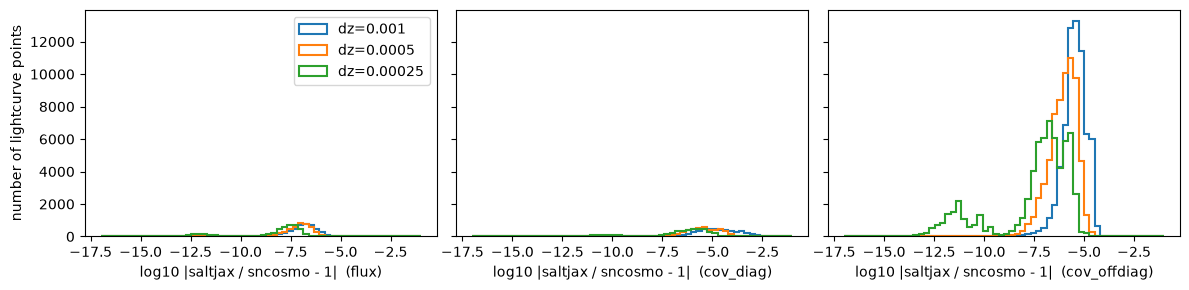

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, key in zip(axes, ["flux", "cov_diag", "cov_offdiag"]):
    for dz, res in model_checks.items():
        ax.hist(np.log10(res[key] + 1e-17), bins=60, range=(-17, -1), histtype="step", lw=1.5, label=f"dz={dz:g}")
    ax.set_xlabel(f"log10 |saltjax / sncosmo - 1|  ({key})")
axes[0].set_ylabel("number of lightcurve points")
axes[0].legend()
fig.tight_layout()

With the default `dz`, the `saltjax` fluxes match sncosmo to about $10^{-8}$ (median) and better than $10^{-6}$ at worst,
and the model covariances to about $10^{-6}$ (median) and $10^{-4}$ at worst. The differences shrink quickly as `dz` decreases:
they come only from the redshift tabulation.

### At the earliest phases

The lightcurves above have few points in the edge intervals. To test the edge rule on band fluxes, we build synthetic
points at rest-frame phases between $-20$ and $-18.4$ days (the first interval of $M_0$/$M_1$ and of the LCRV/errscale surfaces)
for 50 SNe, in the three bands, and compare again, keeping all points (`threshold=0`). We use the default `dz` and a 5 times finer one.

In [10]:
early = index[:50]
p_early = np.linspace(-19.99, -18.4, 12)
rows = [(name, j, truth.loc[name, "t0"] + p * (1 + truth.loc[name, "z"]), b, 1., 1., 30.)
        for name in early for j, (p, b) in enumerate((p, b) for p in p_early for b in bands)]
early_data = pd.DataFrame(rows, columns=["target", "obs", "time", "band", "flux", "fluxerr", "zp"]).set_index(["target", "obs"])
thetas_early = np.column_stack([truth.loc[early, "t0"], np.full(len(early), 1e-3),
                                rng.normal(0, 1.5, len(early)), rng.normal(0, 0.15, len(early))])
early_checks = {}
with jax.enable_x64(True):
    for dz in [2.5e-4, 5e-5]:
        tables = saltjax.build_tables(bands, 0., truth["z"].max(), ebv_max=ebv_max, dz=dz)
        arr = saltjax.pack_lightcurves(early_data, targets, tables, indexes=early, phase_range=None)
        early_checks[dz] = compare_packed(arr, tables, thetas_early, [truth.loc[s] for s in early], threshold=0.)
pd.DataFrame({(f"dz={dz:g}", stat): {k: getattr(np, stat)(v) for k, v in res.items()}
              for dz, res in early_checks.items() for stat in ["median", "max"]}).T.style.format("{:.1e}")

With the default `dz`, the worst points are worse than above (see the table). No flux threshold is applied here, and at these phases
the SN is faint and its colours change fast, so the redshift tabulation matters more. With `dz` five times finer, the differences drop by several orders of magnitude,
to a few $10^{-8}$ at worst. So the residual comes from the tabulation; the edge rule itself is reproduced exactly.

## Fits without model covariance

We fit all the SNe with {func}`saltjax.fit_salt`, starting from a data-driven guess (no truth needed). As reference, we fit
the first 200 with sncosmo through `skysurvey.lcfit.fit_salt`, started from the truth, with wide bounds and without
random scatter of the starting point (so that the bounds play no role). Both use the data between $-10$ and $+40$ rest-frame days.

In [11]:
P = ["t0", "x0", "x1", "c"]
NREF = 200
results = {}
for modelcov in [False, True]:
    jres = saltjax.fit_salt(data, targets, indexes=index, modelcov=modelcov)
    sres = fit_salt(dset, indexes=index[:NREF], modelcov=modelcov, bounds={"t0": 15, "x1": 5, "c": 1},
                    in_scatter={}, warn=False).astype(float)
    results[modelcov] = (jres, sres)
jres[["t0", "x0", "x1", "c", "t0_err", "x1_err", "c_err", "chi2", "ndof", "converged"]].head()

,t0,x0,x1,c,t0_err,x1_err,c_err,chi2,ndof,converged
0,59081.556432,0.001424,-1.863330,-0.002289,0.107501,0.064594,0.024515,9.820462,44.0,True
1,59028.370076,0.014542,1.241375,-0.129149,0.088688,0.046953,0.025011,3.720745,35.0,True
2,59007.831680,0.000649,-2.187028,-0.013614,0.094921,0.096318,0.025119,11.119199,37.0,True
3,59025.743246,0.000257,0.658740,-0.012105,0.158116,0.180456,0.027654,53.414014,49.0,True
4,59057.887000,0.000996,0.527519,0.005415,0.098559,0.076812,0.024465,7.548403,34.0,True


,median |diff| / sigma,max |diff| / sigma,median |err ratio - 1|,max |err ratio - 1|
t0,5.6e-04,9.7e-03,1.5e-05,1.0e-03
x0,3.6e-04,1.0e-02,1.6e-04,7.0e-03
x1,4.3e-04,8.8e-03,4.5e-05,1.1e-02
c,3.6e-04,9.5e-03,1.4e-04,4.7e-03


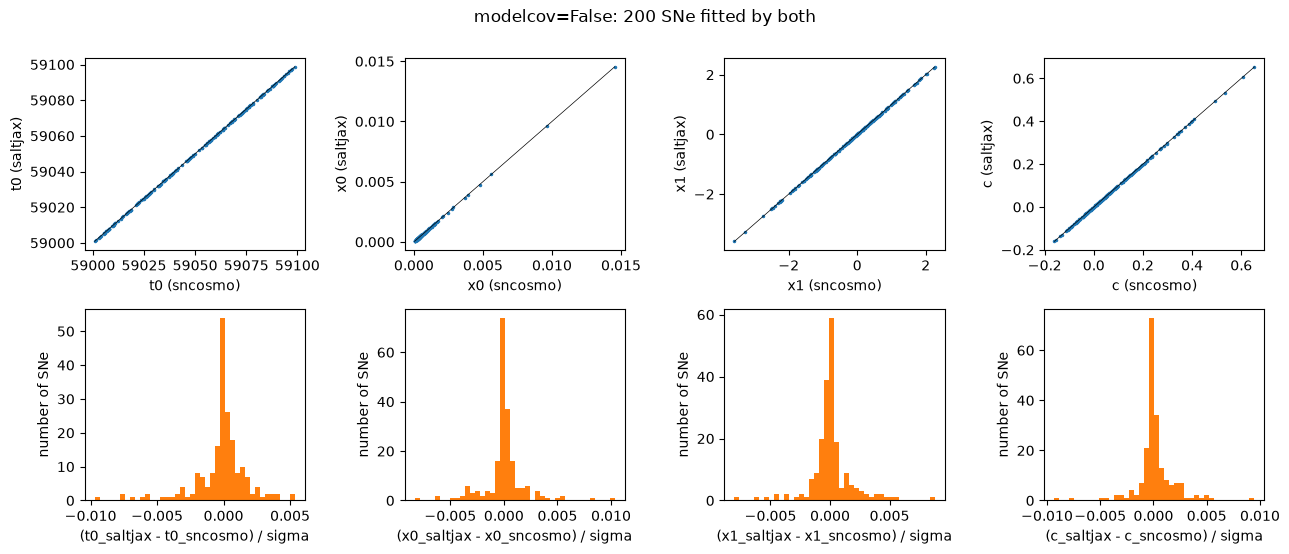

In [12]:
def compare_fits(modelcov):
    jres, sres = results[modelcov]
    c = sres.index
    diff = pd.DataFrame({p: (jres.loc[c, p] - sres[p]) / sres[f"{p}_err"] for p in P})
    eratio = pd.DataFrame({p: jres.loc[c, f"{p}_err"] / sres[f"{p}_err"] - 1 for p in P})
    fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
    for j, p in enumerate(P):
        axes[0, j].plot(sres[p], jres.loc[c, p], ".", ms=3)
        axes[0, j].plot(*[[sres[p].min(), sres[p].max()]] * 2, "k-", lw=0.5)
        axes[0, j].set(xlabel=f"{p} (sncosmo)", ylabel=f"{p} (saltjax)")
        axes[1, j].hist(diff[p], bins=40, color="C1")
        axes[1, j].set(xlabel=f"({p}_saltjax - {p}_sncosmo) / sigma", ylabel="number of SNe")
    fig.suptitle(f"modelcov={modelcov}: {len(c)} SNe fitted by both", y=1.0)
    fig.tight_layout()
    return pd.DataFrame({"median |diff| / sigma": diff.abs().median(), "max |diff| / sigma": diff.abs().max(),
                         "median |err ratio - 1|": eratio.abs().median(), "max |err ratio - 1|": eratio.abs().max()})

fit_checks = {False: compare_fits(False)}
fit_checks[False].style.format("{:.1e}")

The two fitters agree to about $10^{-2}\sigma$ at worst, with a median below $10^{-3}\sigma$. Their errors agree to about $10^{-4}$ (median),
and to the percent level at worst.

## Fits with model covariance

With `modelcov=True`, `sncosmo.fit_lc` fits without model covariance, then refits with the covariance computed at the
start of each refit, until the parameters move by less than $0.1\sigma$. `saltjax` does the same.

,median |diff| / sigma,max |diff| / sigma,median |err ratio - 1|,max |err ratio - 1|
t0,4.8e-04,1.2e-02,5.3e-05,1.5e-02
x0,2.1e-03,1.4e-02,3.4e-04,6.4e-03
x1,6.2e-04,9.7e-03,1.3e-04,1.1e-02
c,2.1e-03,1.3e-02,1.8e-04,4.1e-03


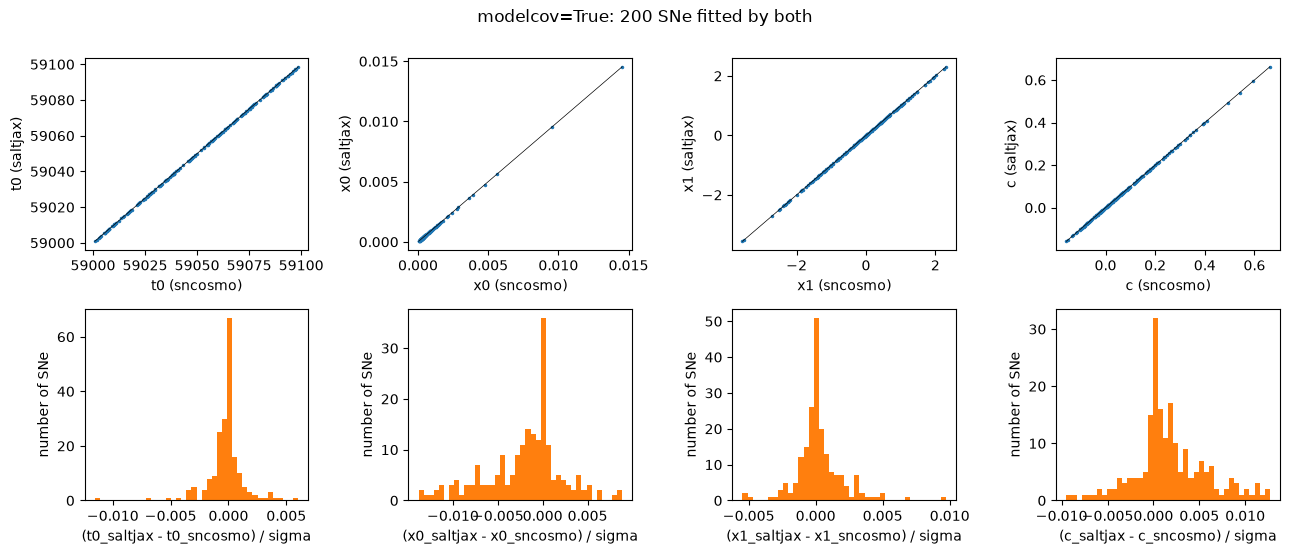

In [13]:
fit_checks[True] = compare_fits(True)
fit_checks[True].style.format("{:.1e}")

In [14]:
jres = results[True][0]
print(f"converged: {jres['converged'].sum()}/{len(jres)}; number of refits: "
      f"{jres['nrefit'].value_counts().sort_index().to_dict()}")

converged: 798/798; number of refits: {1: 98, 2: 700}


With the model covariance, the agreement is at the same level: about $10^{-2}\sigma$ at worst for the parameters, and the percent level at worst
for the errors. Every SN converges, in one to a few refits, as in sncosmo.

## The $\chi^2$ at both solutions

The remaining differences come from the convergence tolerance of the fits. To check it, we compute **sncosmo's own**
$\chi^2$ (`sncosmo.chisq`, without model covariance) at the two solutions of the `modelcov=False` fits, on the same data.

In [15]:
def sncosmo_lc(name, phase_range=(-10, 40)):
    lc, row = data.loc[name], truth.loc[name]
    lc = lc.rename(columns={"mjd": "time"})
    ph = (lc["time"] - row.t0) / (1 + row.z)
    lc = lc[(ph >= phase_range[0]) & (ph <= phase_range[1])]
    return {k: lc[k].to_numpy() for k in ["time", "band", "flux", "fluxerr", "zp", "zpsys"]}

jres, sres = results[False]
dchi2 = []
for name in sres.index:
    lc, row = sncosmo_lc(name), truth.loc[name]
    chi2_jax = sncosmo.chisq(lc, sncosmo_model(row, jres.loc[name, P].to_numpy()))
    chi2_snc = sncosmo.chisq(lc, sncosmo_model(row, sres.loc[name, P].to_numpy()))
    dchi2.append(chi2_snc - chi2_jax)
dchi2 = np.asarray(dchi2)
print(f"chi2(sncosmo solution) - chi2(saltjax solution): min {dchi2.min():.1e}, "
      f"median {np.median(dchi2):.1e}, max {dchi2.max():.1e}")
print(f"saltjax chi2 lower, or equal within 1e-6, for {np.mean(dchi2 >= -1e-6):.0%} of the SNe")

chi2(sncosmo solution) - chi2(saltjax solution): min 4.4e-13, median 2.5e-06, max 1.4e-04
saltjax chi2 lower, or equal within 1e-6, for 100% of the SNe


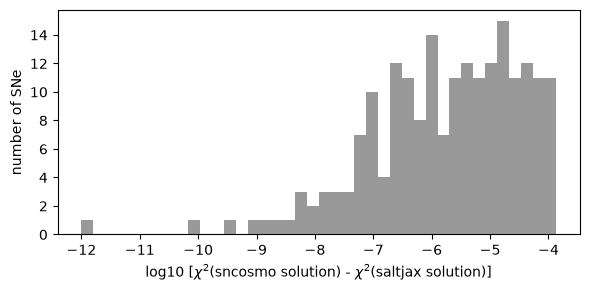

In [16]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(np.log10(np.clip(dchi2, 1e-12, None)), bins=40, color="0.6")
ax.set_xlabel(r"log10 [$\chi^2$(sncosmo solution) - $\chi^2$(saltjax solution)]")
ax.set_ylabel("number of SNe")
fig.tight_layout()

For every SN, sncosmo's own $\chi^2$ is as low at the `saltjax` solution (within $10^{-6}$), or lower. The differences between the
fitted parameters therefore come from the convergence tolerance of the fits, not from the model.

## Same pulls against the simulated truth

Both fitters give the same pull distributions, $(\hat\theta - \theta_{\rm true})/\sigma$.
With `modelcov=True` the pulls are narrower than one for both. This is expected: the model covariance inflates the errors,
but this simulation includes no intrinsic scatter around the SALT2 model.

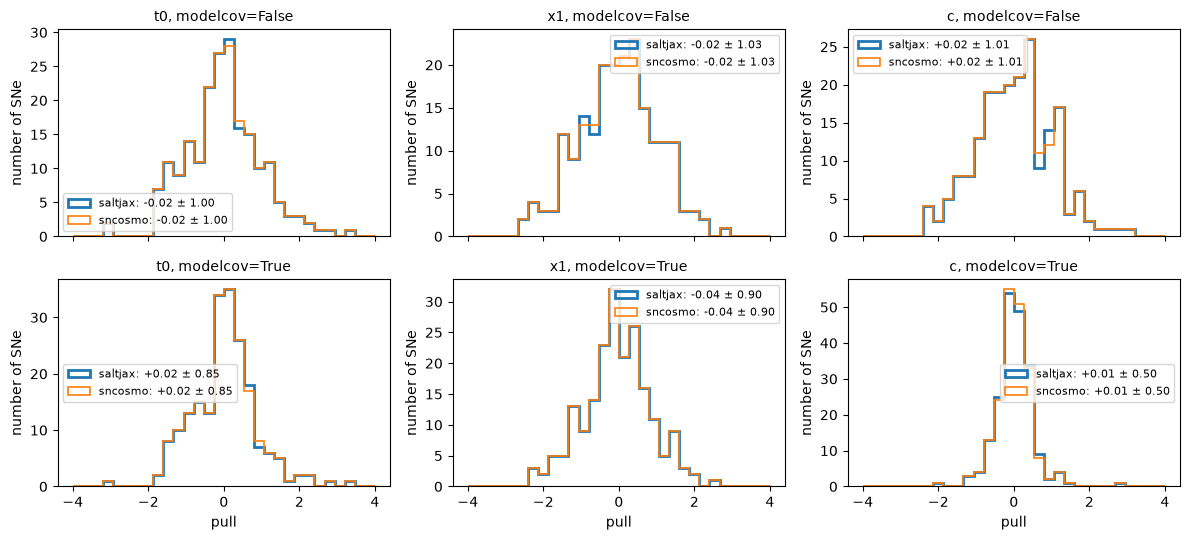

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True)
for row, modelcov in enumerate([False, True]):
    jres, sres = results[modelcov]
    c = sres.index
    for ax, p in zip(axes[row], ["t0", "x1", "c"]):
        for label, res, color in [("saltjax", jres.loc[c], "C0"), ("sncosmo", sres, "C1")]:
            pull = (res[p] - truth.loc[c, p]) / res[f"{p}_err"]
            ax.hist(pull, bins=30, range=(-4, 4), histtype="step", lw=2 if label == "saltjax" else 1.2,
                    color=color, label=f"{label}: {pull.mean():+.2f} ± {pull.std():.2f}")
        ax.set_title(f"{p}, modelcov={modelcov}", fontsize=10)
        ax.set_ylabel("number of SNe")
        ax.legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("pull")
fig.tight_layout()

## Summary

The agreement measured on this page:

In [18]:
d = model_checks[2.5e-4]
summary = {
    "kernel: M0 at random phases (rel. to max)": kernel_diff,
    "edge rule: M0 and errscale, first interval (rel. to max)": max(r["saltjax"].max() for r in edge_check.values()),
    "band flux, default dz (max rel.)": d["flux"].max(),
    "model covariance, default dz (max rel.)": max(d["cov_diag"].max(), d["cov_offdiag"].max()),
    "band flux, earliest phases, default dz (max rel.)": early_checks[2.5e-4]["flux"].max(),
    "model covariance, earliest phases, default dz (max rel.)": max(early_checks[2.5e-4]["cov_diag"].max(),
                                                                    early_checks[2.5e-4]["cov_offdiag"].max()),
    "band flux, earliest phases, dz=5e-5 (max rel.)": early_checks[5e-5]["flux"].max(),
}
for mc in [False, True]:
    summary[f"parameters, modelcov={mc} (max |diff| / sigma)"] = fit_checks[mc]["max |diff| / sigma"].max()
    summary[f"parameters, modelcov={mc} (median |diff| / sigma, worst parameter)"] = fit_checks[mc]["median |diff| / sigma"].max()
    summary[f"errors, modelcov={mc} (median |ratio - 1|, worst parameter)"] = fit_checks[mc]["median |err ratio - 1|"].max()
    summary[f"errors, modelcov={mc} (max |ratio - 1|)"] = fit_checks[mc]["max |err ratio - 1|"].max()
summary["chi2(sncosmo) - chi2(saltjax), min"] = dchi2.min()
pd.Series(summary, name="measured").to_frame().style.format("{:.1e}")

,measured
kernel: M0 at random phases (rel. to max),2.4e-15
"edge rule: M0 and errscale, first interval (rel. to max)",4.0e-15
"band flux, default dz (max rel.)",4.7e-07
"model covariance, default dz (max rel.)",4.4e-05
"band flux, earliest phases, default dz (max rel.)",1.5e-04
"model covariance, earliest phases, default dz (max rel.)",1.1e-03
"band flux, earliest phases, dz=5e-5 (max rel.)",3.1e-09
"parameters, modelcov=False (max |diff| / sigma)",1.0e-02
"parameters, modelcov=False (median |diff| / sigma, worst parameter)",5.6e-04
"errors, modelcov=False (median |ratio - 1|, worst parameter)",1.6e-04


* **The same model.** The interpolation kernel, including sncosmo's linear rule in the edge phase intervals, is reproduced to machine precision.
  Band fluxes and model covariances match `sncosmo.Model.bandfluxcov`. The only approximation is the redshift tabulation, and its error shrinks with `dz`.
* **The same fits.** With and without model covariance, parameters agree to about $10^{-2}\sigma$ at worst, and errors to about $10^{-4}$ (median) and the percent level at worst.
  sncosmo's own $\chi^2$ is as low at the `saltjax` solution, or lower.
* **The same pulls** against the simulated truth.

## Next steps

* [Quickstart](../quickstart.ipynb): fit your own lightcurves with {func}`saltjax.fit_salt`.
* [Speed](./speed.ipynb): how fast `saltjax` is compared with sncosmo, and how it scales.
* [API reference](../api/index.rst).